In [1]:
!pip install langdetect

     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     - -------------------------------------- 30.7/981.5 kB ? eta -:--:--
     - -------------------------------------- 30.7/981.5 kB ? eta -:--:--
     - -------------------------------------- 30.7/981.5 kB ? eta -:--:--
     - ----------------------------------- 41.0/981.5 kB 196.9 kB/s eta 0:00:05
     --- --------------------------------- 92.2/981.5 kB 375.8 kB/s eta 0:00:03
     --- --------------------------------- 92.2/981.5 kB 375.8 kB/s eta 0:00:03
     ---- ------------------------------- 112.6/981.5 kB 328.2 kB/s eta 0:00:03
     ---- ------------------------------- 112.6/981.5 kB 328.2 kB/s eta 0:00:03
     ------ ----------------------------- 163.8/981.5 kB 393.8 kB/s eta 0:00:03
     ------ ----------------------------- 163.8/981.5 kB 393.8 kB/s eta 0:00:03
     -------- --------------------------- 225.3/981.5 kB 430.1 kB/s eta 0:00:02
     --------- -------------------------- 256.0/981.5 kB 477.2 kB

  DEPRECATION: langdetect is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import re
import warnings
warnings.filterwarnings('ignore')



In [3]:
reviews = pd.read_csv('olist_processed_data/order_reviews_cleaned.csv')

print(f"Total reviews     : {len(reviews)}")
print(f"Columns           : {reviews.columns.tolist()}")
print(f"\nSample:")
print(reviews.head(3))

Total reviews     : 99224
Columns           : ['review_id', 'order_id', 'review_score', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Sample:
                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   

   review_score review_comment_message review_creation_date  \
0             4             no comment  2018-01-18 00:00:00   
1             5             no comment  2018-03-10 00:00:00   
2             5             no comment  2018-02-17 00:00:00   

  review_answer_timestamp  
0     2018-01-18 21:46:59  
1     2018-03-11 03:05:13  
2     2018-02-18 14:36:24  


Sentiment Distribution:
sentiment
positive    76470
negative    14575
neutral      8179
Name: count, dtype: int64

Percentage:
sentiment
positive    77.1%
negative    14.7%
neutral      8.2%
Name: proportion, dtype: str


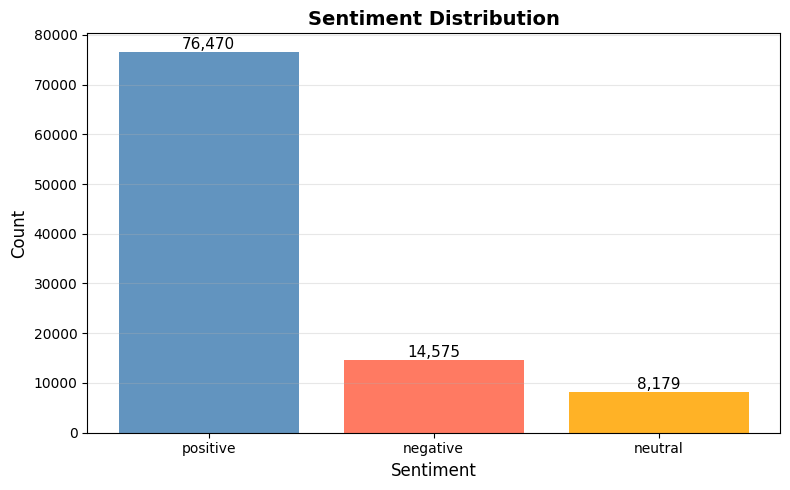

In [4]:
def label_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

reviews['sentiment'] = reviews['review_score'].apply(label_sentiment)


print("Sentiment Distribution:")
print(reviews['sentiment'].value_counts())
print(f"\nPercentage:")
print(reviews['sentiment'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

plt.figure(figsize=(8, 5))
colors = {'positive': 'steelblue', 'neutral': 'orange', 'negative': 'tomato'}
sentiment_counts = reviews['sentiment'].value_counts()
bars = plt.bar(sentiment_counts.index,
               sentiment_counts.values,
               color=[colors[s] for s in sentiment_counts.index],
               alpha=0.85)
plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
def clean_text(text):
    if pd.isna(text) or text == 'no comment':
        return ''
    text = str(text).lower()
    text = re.sub(r'[^a-záàâãéèêíïóôõöúüçñ\s]', '', text)  # keep Portuguese chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

reviews['cleaned_text'] = reviews['review_comment_message'].apply(clean_text)

if 'review_comment_title' in reviews.columns:
    reviews['cleaned_title'] = reviews['review_comment_title'].apply(clean_text)
    reviews['text_combined'] = reviews.apply(
        lambda x: x['cleaned_text'] if x['cleaned_text'] else x['cleaned_title'], axis=1
    )
else:
    reviews['text_combined'] = reviews['cleaned_text']

reviews_with_text = reviews[reviews['text_combined'].str.len() > 0].copy()

print(f"Reviews with text : {len(reviews_with_text)} ({len(reviews_with_text)/len(reviews)*100:.1f}%)")
print(f"Reviews without   : {len(reviews) - len(reviews_with_text)}")
print(f"\nSentiment distribution in text reviews:")
print(reviews_with_text['sentiment'].value_counts())
print(f"\nSample cleaned text:")
print(reviews_with_text[['review_comment_message', 'cleaned_text', 'sentiment']].head(5).to_string(index=False))

Reviews with text : 40791 (41.1%)
Reviews without   : 58433

Sentiment distribution in text reviews:
sentiment
positive    26367
negative    10878
neutral      3546
Name: count, dtype: int64

Sample cleaned text:
                                                                                                                                                        review_comment_message                                                                                                                                                              cleaned_text sentiment
                                                                                                                                         Recebi bem antes do prazo estipulado.                                                                                                                                      recebi bem antes do prazo estipulado  positive
                                                                          Par

In [6]:

X = reviews_with_text['text_combined']
y = reviews_with_text['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=5000,     
    ngram_range=(1, 2),     
    min_df=3,             
    sublinear_tf=True     
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Train size        : {X_train_tfidf.shape[0]} reviews")
print(f"Test size         : {X_test_tfidf.shape[0]} reviews")
print(f"Vocabulary size   : {X_train_tfidf.shape[1]} features")
print(f"\nTop 20 TF-IDF terms:")
feature_names = tfidf.get_feature_names_out()
print(", ".join(feature_names[:20]))

Train size        : 32632 reviews
Test size         : 8159 reviews
Vocabulary size   : 5000 features

Top 20 TF-IDF terms:
abaixo, abaixo do, aberta, aberto, abraço, abri, abrir, absurdo, acabado, acabamento, acabamento perfeito, acabei, acabou, acessível, acessórios, achando, achando que, achei, achei material, achei muito


In [7]:
lr_sentiment = LogisticRegression(
    random_state=42, max_iter=1000,
    class_weight='balanced', C=1.0
)
lr_sentiment.fit(X_train_tfidf, y_train)
y_pred_lr  = lr_sentiment.predict(X_test_tfidf)


nb_sentiment = MultinomialNB(alpha=0.1)
nb_sentiment.fit(X_train_tfidf, y_train)
y_pred_nb  = nb_sentiment.predict(X_test_tfidf)

print("LOGISTIC REGRESSION")

print(classification_report(y_test, y_pred_lr,
      target_names=['negative', 'neutral', 'positive']))

print("\nNAIVE BAYES")

print(classification_report(y_test, y_pred_nb,
      target_names=['negative', 'neutral', 'positive']))

lr_acc = (y_pred_lr == y_test).mean()
nb_acc = (y_pred_nb == y_test).mean()
print(f"\nAccuracy Comparison:")
print(f"  Logistic Regression : {lr_acc:.4f}")
print(f"  Naive Bayes         : {nb_acc:.4f}")
best_sentiment_model = 'Logistic Regression' if lr_acc >= nb_acc else 'Naive Bayes'
print(f"  Best Model          : {best_sentiment_model}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    negative       0.79      0.79      0.79      2176
     neutral       0.24      0.46      0.31       709
    positive       0.95      0.83      0.89      5274

    accuracy                           0.79      8159
   macro avg       0.66      0.69      0.66      8159
weighted avg       0.85      0.79      0.81      8159


NAIVE BAYES
              precision    recall  f1-score   support

    negative       0.75      0.88      0.81      2176
     neutral       0.29      0.14      0.19       709
    positive       0.91      0.91      0.91      5274

    accuracy                           0.83      8159
   macro avg       0.65      0.64      0.64      8159
weighted avg       0.81      0.83      0.82      8159


Accuracy Comparison:
  Logistic Regression : 0.7888
  Naive Bayes         : 0.8348
  Best Model          : Naive Bayes


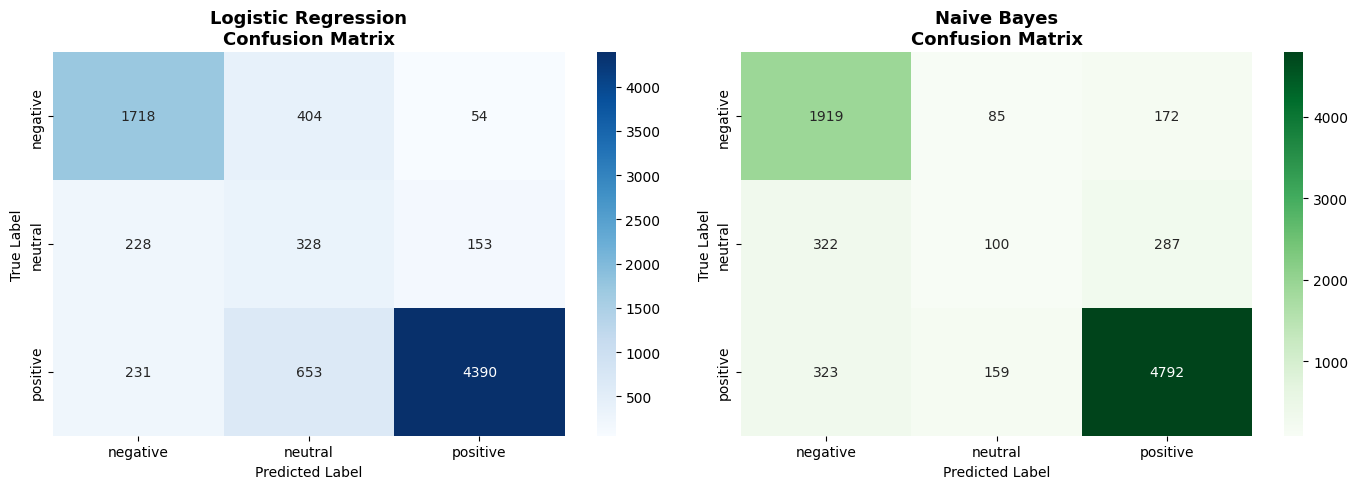

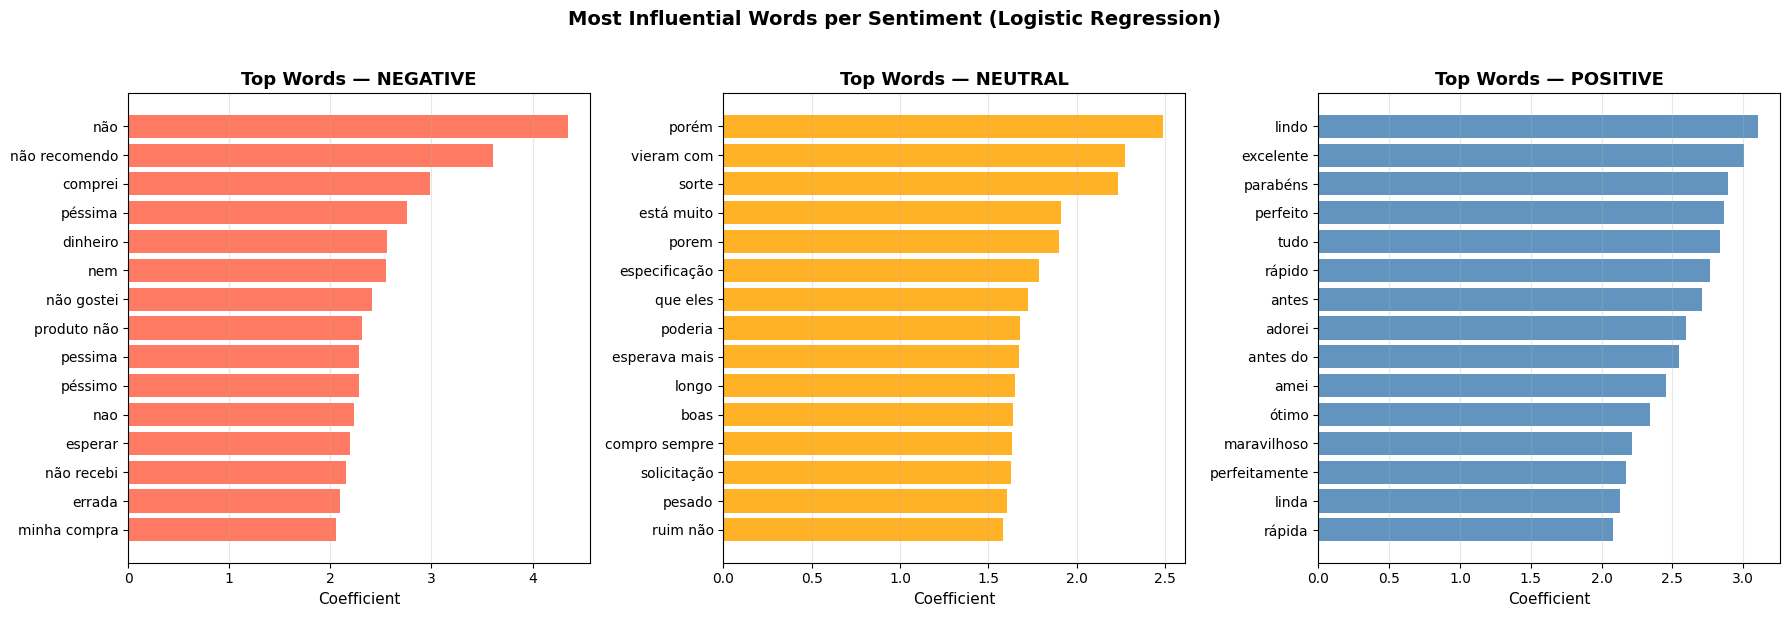

In [8]:
labels = ['negative', 'neutral', 'positive']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')


cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('Naive Bayes\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sentiment_classes = lr_sentiment.classes_
colors_map = {'negative': 'tomato', 'neutral': 'orange', 'positive': 'steelblue'}

for i, sentiment_class in enumerate(sentiment_classes):
    coefs = lr_sentiment.coef_[i]
    top_indices = coefs.argsort()[-15:][::-1]
    top_words   = [feature_names[j] for j in top_indices]
    top_values  = coefs[top_indices]

    axes[i].barh(top_words, top_values,
                 color=colors_map.get(sentiment_class, 'gray'), alpha=0.85)
    axes[i].set_title(f'Top Words — {sentiment_class.upper()}',
                      fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Coefficient', fontsize=11)
    axes[i].invert_yaxis()
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('Most Influential Words per Sentiment (Logistic Regression)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Predicted vs Actual Sentiment (reviews with text):
Predicted  negative  neutral  positive
Actual                                
negative       9131     1495       252
neutral         641     2418       487
positive       1034     3120     22213

Average Star Rating per Predicted Sentiment:
predicted_sentiment
negative    1.51
neutral     3.18
positive    4.74
Name: review_score, dtype: float64


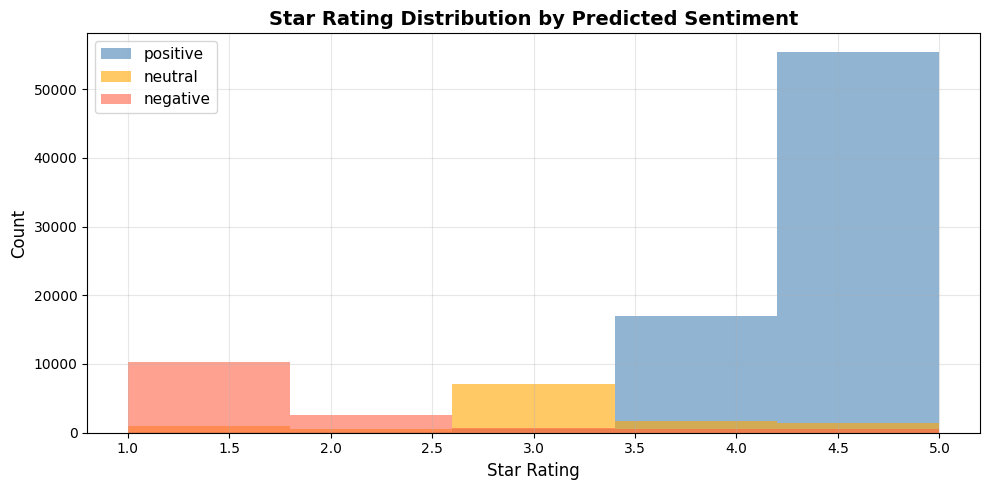

In [9]:
reviews['predicted_sentiment'] = reviews['sentiment'] 

reviews_with_text['predicted_sentiment'] = lr_sentiment.predict(
    tfidf.transform(reviews_with_text['text_combined'])
)
reviews.update(reviews_with_text[['predicted_sentiment']])

print("Predicted vs Actual Sentiment (reviews with text):")
comparison = pd.crosstab(
    reviews_with_text['sentiment'],
    reviews_with_text['predicted_sentiment'],
    rownames=['Actual'],
    colnames=['Predicted']
)
print(comparison)


print(f"\nAverage Star Rating per Predicted Sentiment:")
print(reviews.groupby('predicted_sentiment')['review_score'].mean().round(2))


plt.figure(figsize=(10, 5))
for sentiment, color in [('positive', 'steelblue'), ('neutral', 'orange'), ('negative', 'tomato')]:
    subset = reviews[reviews['predicted_sentiment'] == sentiment]['review_score']
    plt.hist(subset, bins=5, alpha=0.6, label=sentiment, color=color)
plt.title('Star Rating Distribution by Predicted Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
import os
os.makedirs('olist_processed_data', exist_ok=True)

reviews.to_csv('olist_processed_data/reviews_with_sentiment.csv', index=False)
print("Saved: reviews_with_sentiment.csv")


print(f"""

Total Reviews      : {len(reviews)}
Reviews with Text  : {len(reviews_with_text)} ({len(reviews_with_text)/len(reviews)*100:.1f}%)

Sentiment Labels:
  Positive (4-5 stars) : {(reviews['sentiment']=='positive').sum()}
  Neutral  (3 stars)   : {(reviews['sentiment']=='neutral').sum()}
  Negative (1-2 stars) : {(reviews['sentiment']=='negative').sum()}

MODEL PERFORMANCE:
  Logistic Regression : {lr_acc:.4f}
  Naive Bayes         : {nb_acc:.4f}
  Best Model          : {best_sentiment_model}
""")

Saved: reviews_with_sentiment.csv


Total Reviews      : 99224
Reviews with Text  : 40791 (41.1%)

Sentiment Labels:
  Positive (4-5 stars) : 76470
  Neutral  (3 stars)   : 8179
  Negative (1-2 stars) : 14575

MODEL PERFORMANCE:
  Logistic Regression : 0.7888
  Naive Bayes         : 0.8348
  Best Model          : Naive Bayes

